In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load the dataset
df = pd.read_csv("../data/sl_economic_crisis_data.csv")
df.head()
df.columns

Index(['USD_Rate', 'Diesel_Price_Rs', 'Petrol_Price_Rs', 'Lorry_Quota_L',
       'Bike_Quota_L', 'Rice_Price_Rs', 'Bread_Price_Rs', 'Power_Cut_Hours',
       'Economic_Status', 'Power_Cut_Warning'],
      dtype='str')

C:\Users\DHANUwa\AppData\Local\Temp\ipykernel_6028\1006761653.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Economic_Status', palette='viridis', ax=axes[0, 0])
C:\Users\DHANUwa\AppData\Local\Temp\ipykernel_6028\1006761653.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Power_Cut_Warning', y='USD_Rate', palette='Set2', ax=axes[1,0])
C:\Users\DHANUwa\AppData\Local\Temp\ipykernel_6028\1006761653.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['No Power Cut (0)', 'Power Cut Expected (1)'])


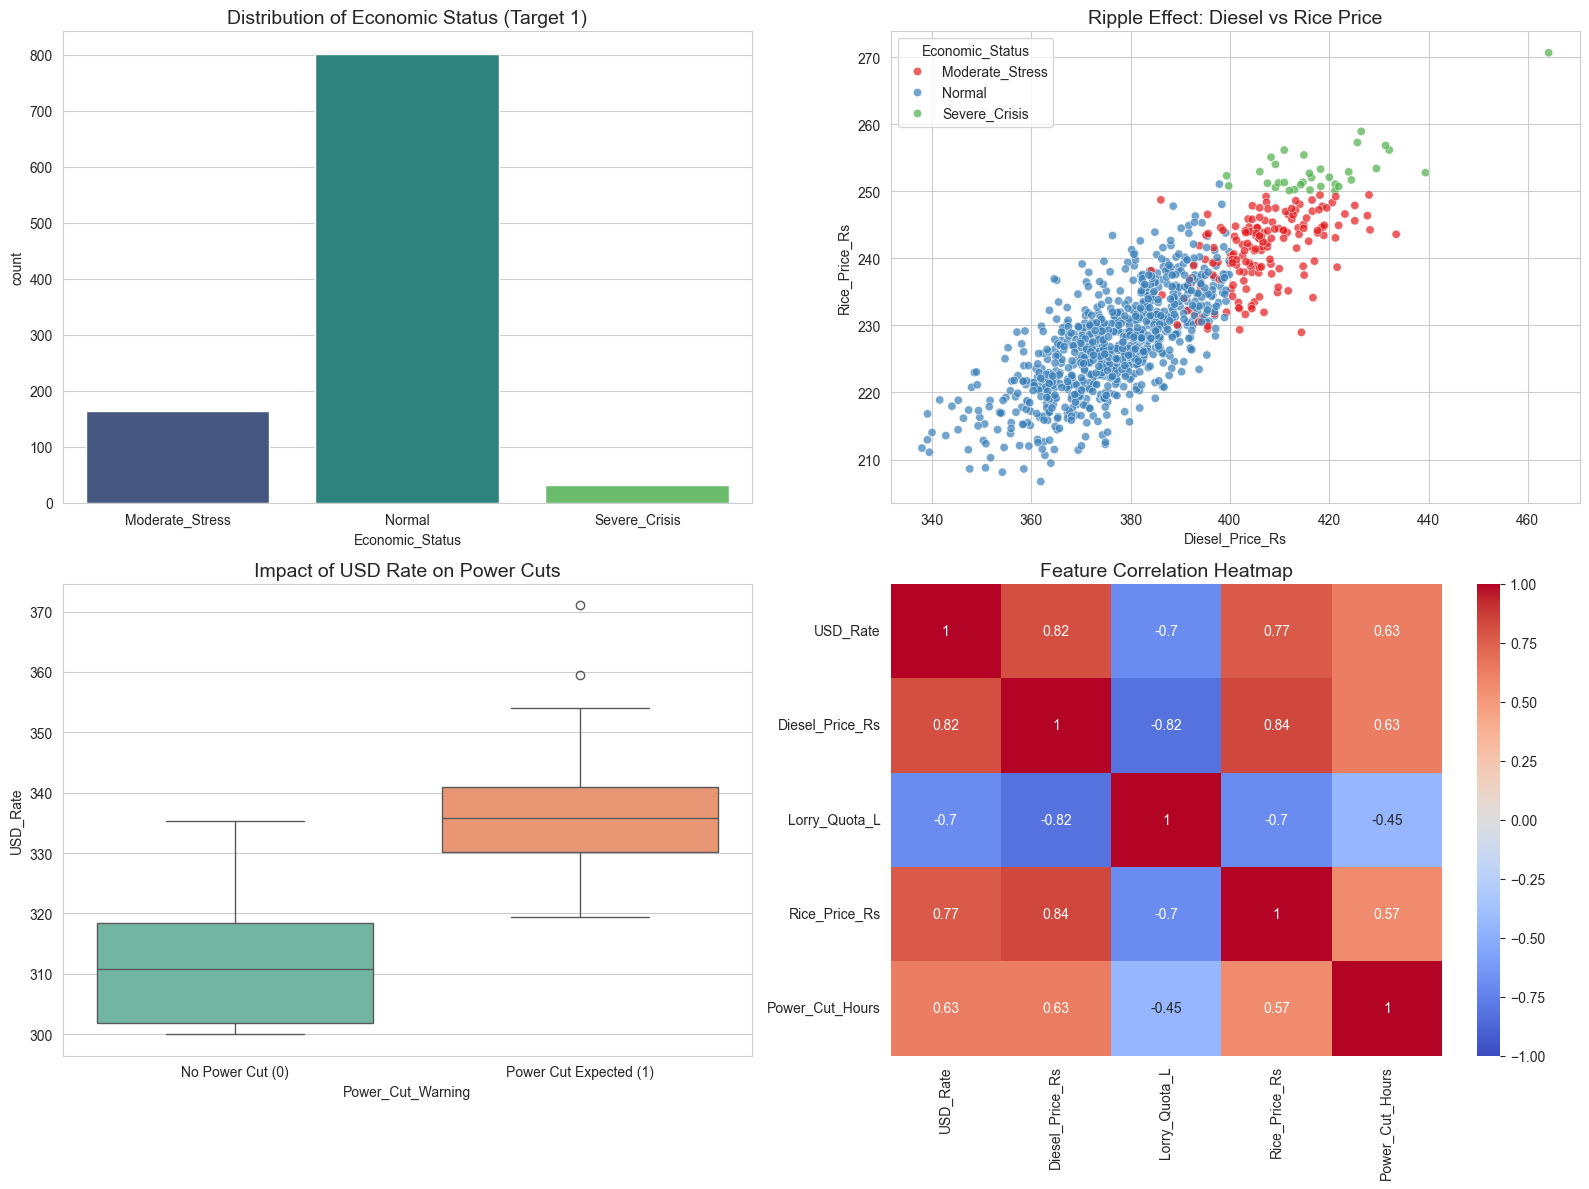

In [11]:
# ප්‍රස්ථාර සඳහා Style එකක් සැකසීම
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Target Class Balance (පන්ති බෙදී ඇති ආකාරය) ---
# ML වලදී පන්ති සමබරද කියලා බලන්නම ඕනේ.
sns.countplot(data=df, x='Economic_Status', palette='viridis', ax=axes[0, 0])
axes[0,0].set_title('Distribution of Economic Status (Target 1)', fontsize=14)

# --- Plot 2: Ripple Effect (ඩීසල් සහ සහල් මිල අතර සම්බන්ධය) ---
sns.scatterplot(data=df, x='Diesel_Price_Rs', y='Rice_Price_Rs', hue='Economic_Status', palette='Set1', alpha=0.7, ax=axes[0,1])
axes[0,1].set_title('Ripple Effect: Diesel vs Rice Price', fontsize=14)

# --- Plot 3: ඩොලර් අනුපාතය සහ විදුලි කප්පාදු අවදානම ---
sns.boxplot(data=df, x='Power_Cut_Warning', y='USD_Rate', palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Impact of USD Rate on Power Cuts', fontsize=14)
axes[1,0].set_xticklabels(['No Power Cut (0)', 'Power Cut Expected (1)'])

# --- Plot 4: Correlation Heatmap (විචල්‍යයන් අතර සම්බන්ධතාවය) ---
# මේකෙන් පෙන්වන්නේ මොන Feature එකද අනිත් ඒවාට ගොඩක්ම බලපාන්නේ කියලා.
corr = df[['USD_Rate', 'Diesel_Price_Rs', 'Lorry_Quota_L', 'Rice_Price_Rs', 'Power_Cut_Hours']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1,1])
axes[1,1].set_title('Feature Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()